In [2]:
import pandas as pd
import re
import string
import numpy as np
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer



In [3]:
data = pd.read_csv('imdb_labelled.txt', sep='\t', names=['text', 'label'])

In [4]:
data.head()

,text,label
0,"A very, very, very slow-moving, aimless movie ...",0
1,Not sure who was more lost - the flat characte...,0
2,Attempting artiness with black & white and cle...,0
3,Very little music or anything to speak of.,0
4,The best scene in the movie was when Gerardo i...,1


In [5]:
data['label'].value_counts()

label
1    386
0    362
Name: count, dtype: int64

In [6]:
data.shape

(748, 2)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    748 non-null    object
 1   label   748 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 11.8+ KB


In [8]:
data['text']= data['text'].str.lower()

In [9]:

data["text"] = data["text"].str.replace(
    rf"[{re.escape(string.punctuation)}]",
    " ",
    regex=True
)

In [10]:
# i need to code to check the word "haven't" is in the text column after preprocessing
data[data['text'].str.contains("haven't")]

,text,label


In [11]:
#i need check for punctuation in the text column after preprocessing

data[data['text'].str.contains(rf"[{re.escape(string.punctuation)}]", regex=True)]

,text,label


In [12]:
data[data['text'].str.contains(r'\d')].count()

text     59
label    59
dtype: int64

In [13]:
data["text"] = data["text"].str.replace(r"\d+", " ", regex=True)

In [14]:
data[data['text'].str.contains(r'\d')].count()

text     0
label    0
dtype: int64

In [15]:
stop_words = set(stopwords.words("english"))
stop_words = stop_words - {"no", "not", "nor", "never"}

data["text"] = data["text"].apply(
    lambda x: " ".join(
        [word for word in word_tokenize(x) if word not in stop_words]
    )
)


In [16]:

pd.set_option('display.max_colwidth', None)
data.head()

,text,label
0,slow moving aimless movie distressed drifting young man,0
1,not sure lost flat characters audience nearly half walked,0
2,attempting artiness black white clever camera angles movie disappointed became even ridiculous acting poor plot lines almost non existent,0
3,little music anything speak,0
4,best scene movie gerardo trying find song keeps running head,1


In [17]:
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet



lemmatizer = WordNetLemmatizer()

def get_pos(tag):
    if tag.startswith("J"):
        return wordnet.ADJ
    elif tag.startswith("V"):
        return wordnet.VERB
    elif tag.startswith("N"):
        return wordnet.NOUN
    elif tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN

data["text"] = data["text"].apply(
    lambda x: " ".join(
        lemmatizer.lemmatize(word, get_pos(pos))
        for word, pos in pos_tag(word_tokenize(x))
    )
)


In [18]:
data.head()

,text,label
0,slow move aimless movie distress drift young man,0
1,not sure lose flat character audience nearly half walk,0
2,attempt artiness black white clever camera angle movie disappoint become even ridiculous act poor plot line almost non existent,0
3,little music anything speak,0
4,best scene movie gerardo try find song keep run head,1


In [19]:
data["text"] = data["text"].str.replace(r"\s+", " ", regex=True).str.strip()

TASK-2

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [21]:
X = data["text"]
y = data["label"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),   
    max_df=0.9,           
    min_df=1              
)

In [24]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape: ", X_test_tfidf.shape)

Train TF-IDF shape: (598, 7084)
Test TF-IDF shape:  (150, 7084)


In [25]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

lg_prediction_score = classification_report(y_pred,y_test)

print(lg_prediction_score)

              precision    recall  f1-score   support

           0       0.68      0.79      0.74        63
           1       0.83      0.74      0.78        87

    accuracy                           0.76       150
   macro avg       0.76      0.76      0.76       150
weighted avg       0.77      0.76      0.76       150



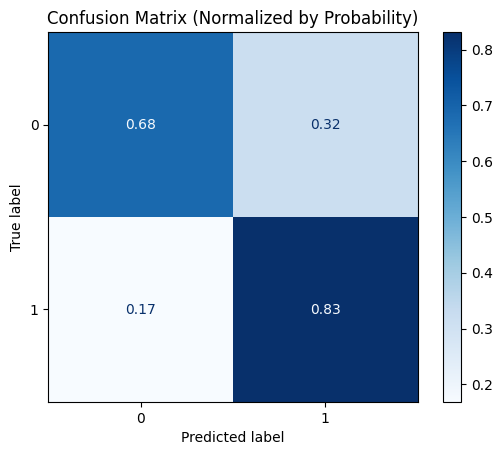

In [26]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', normalize='true')
plt.title("Confusion Matrix (Normalized by Probability)")
plt.show()

In [27]:
from sklearn.svm import SVC


svc = SVC(C=10, gamma=0.1, probability=True, random_state=42)

svc_model = svc.fit(X_train_tfidf, y_train)

svc_y_pred = svc_model.predict(X_test_tfidf)

svc_prediction_score = classification_report(svc_y_pred,y_test)

print(svc_prediction_score)

              precision    recall  f1-score   support

           0       0.78      0.79      0.79        72
           1       0.81      0.79      0.80        78

    accuracy                           0.79       150
   macro avg       0.79      0.79      0.79       150
weighted avg       0.79      0.79      0.79       150



In [28]:
from sklearn.model_selection import GridSearchCV
svc = SVC(probability=True, random_state=42)

param_grid = {
    'kernel': ['rbf'],
    'C': [0.1, 1, 10],
    'gamma': [0.01, 0.1, 1]
}

grid = GridSearchCV(
    svc,
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_tfidf, y_train)

GridSearchCV(cv=5, estimator=SVC(probability=True, random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1],
                         'kernel': ['rbf']},
             scoring='roc_auc')

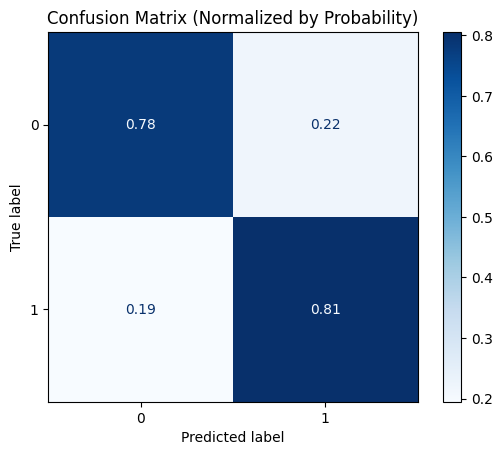

In [29]:
ConfusionMatrixDisplay.from_predictions(y_test, svc_y_pred, cmap='Blues', normalize='true')
plt.title("Confusion Matrix (Normalized by Probability)")
plt.show()

In [30]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# Naive Bayes model (best match for TF-IDF text features)
nb = MultinomialNB(alpha=1.0)

nb_model = nb.fit(X_train_tfidf, y_train)

nb_y_pred = nb_model.predict(X_test_tfidf)

# IMPORTANT: classification_report expects (y_true, y_pred)
nb_prediction_score = classification_report(y_test, nb_y_pred)

print(nb_prediction_score)

              precision    recall  f1-score   support

           0       0.79      0.74      0.77        73
           1       0.77      0.82      0.79        77

    accuracy                           0.78       150
   macro avg       0.78      0.78      0.78       150
weighted avg       0.78      0.78      0.78       150



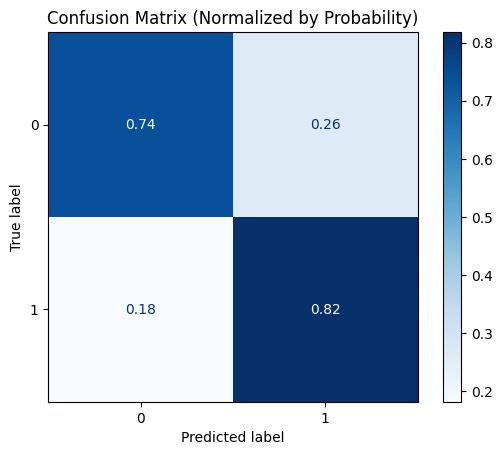

In [31]:
ConfusionMatrixDisplay.from_predictions(y_test, nb_y_pred, cmap='Blues', normalize='true')
plt.title("Confusion Matrix (Normalized by Probability)")
plt.show()

In [32]:
feature_names = tfidf.get_feature_names_out()
coef = model.coef_[0]

top_pos = sorted(zip(feature_names, coef), key=lambda x: x[1], reverse=True)[:15]
top_neg = sorted(zip(feature_names, coef), key=lambda x: x[1])[:15]

print("\nTop Positive Features:")
for w, c in top_pos:
    print(f"{w:25s} {c:.4f}")

print("\nTop Negative Features:")
for w, c in top_neg:
    print(f"{w:25s} {c:.4f}")


Top Positive Features:
give                      1.0349
well                      0.9722
good                      0.9462
great                     0.9005
enjoy                     0.8316
excellent                 0.8271
wonderful                 0.7764
film                      0.7658
funny                     0.7657
brilliant                 0.7442
play                      0.7218
character                 0.6764
beautiful                 0.6029
think                     0.5992
love                      0.5797

Top Negative Features:
bad                       -2.7617
awful                     -1.1743
not                       -1.1392
script                    -0.9816
nothing                   -0.9348
even                      -0.9309
plot                      -0.9220
stupid                    -0.8922
waste                     -0.8798
would                     -0.8645
no                        -0.8643
avoid                     -0.6695
terrible                  -0.6361
slow           

In [33]:
from sklearn.metrics import accuracy_score
lg_accuracy = accuracy_score(y_test, y_pred)
svc_accuracy = accuracy_score(y_test, svc_y_pred)
nb_accuracy = accuracy_score(y_test, nb_y_pred)
print(f"Logistic Regression Accuracy: {lg_accuracy:.4f}")
print(f"SVC Accuracy: {svc_accuracy:.4f}")
print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")

Logistic Regression Accuracy: 0.7600
SVC Accuracy: 0.7933
Naive Bayes Accuracy: 0.7800


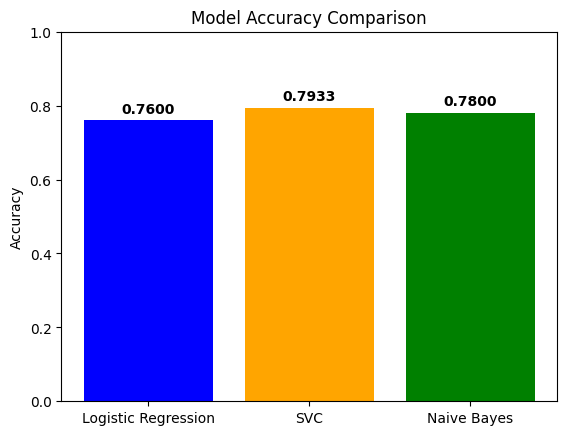

In [34]:

models = ['Logistic Regression', 'SVC', 'Naive Bayes']
accuracies = [lg_accuracy, svc_accuracy, nb_accuracy]
plt.bar(models, accuracies, color=['blue', 'orange', 'green'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()


TASK 3

In [35]:
import numpy as np
from sklearn.metrics import accuracy_score
import pandas as pd
from datasets import Dataset
! pip install transformers
from transformers import BertTokenizer, BertForSequenceClassification, TrainingArguments, Trainer,AutoTokenizer
from sklearn.model_selection import train_test_split


/Applications/main/pyhton/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Applications/main/pyhton/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
X = data["text"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_df = pd.DataFrame({"text": X_train.values, "label": y_train.values})
test_df  = pd.DataFrame({"text": X_test.values,  "label": y_test.values})

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df.reset_index(drop=True))

In [37]:
from transformers import AutoModelForSequenceClassification

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)



Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [38]:
def tok(batch):
    return tokenizer(batch["text"], truncation=True)

train_tok = train_ds.map(tok, batched=True)
test_tok  = test_ds.map(tok, batched=True)

Map:   0%|          | 0/598 [00:00<?, ? examples/s]

Map: 100%|██████████| 150/150 [00:00<00:00, 29749.65 examples/s]


In [39]:
training_args = TrainingArguments(
    output_dir="task3_bert_outputs",
    num_train_epochs=1,                 
    per_device_train_batch_size=4,      
    per_device_eval_batch_size=4,
         
    logging_steps=20,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    tokenizer=tokenizer
)

/var/folders/73/mpjtryh12nj3xz35btdcvkwr0000gn/T/ipykernel_1071/3146039110.py:11: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [40]:
accuracy_score(y_test, y_pred)

0.76

In [41]:
import numpy as np

results = X_test.reset_index(drop=True).to_frame(name="text")
results["true_label"] = y_test.reset_index(drop=True)
results["predicted_label"] = y_pred

results["correct"] = results["true_label"] == results["predicted_label"]

results

,text,true_label,predicted_label,correct
0,wonderful inspiring watch hope get release video dvd,1,1,True
1,anyway plot flow smoothly male bond scene hoot,1,0,False
2,unless visually collect extant film austen work skip one,0,1,False
3,love really scary,1,1,True
4,one fail create real suspense,0,1,False
...,...,...,...,...
145,no plot whatsoever,0,0,True
146,not good,0,1,False
147,word embarrassing,0,0,True
148,easily none cartoon make laugh tender way get dark sitcom orient teenager,1,0,False


In [42]:
errors = results[results["correct"] == False]
errors.shape

(36, 4)

In [43]:
print("Total test samples:", len(results))
print("Total errors:", len(errors))

Total test samples: 150
Total errors: 36


In [44]:
false_positive = errors[
    (errors["true_label"] == 0) & (errors["predicted_label"] == 1)
]

false_negative = errors[
    (errors["true_label"] == 1) & (errors["predicted_label"] == 0)
]

print("False Positives:", len(false_positive))
print("False Negatives:", len(false_negative))


False Positives: 23
False Negatives: 13


In [45]:
print("False Positives Examples:\n")
for text in false_positive["text"].head(3):
    print("-", text)

print("\nFalse Negatives Examples:\n")
for text in false_negative["text"].head(3):
    print("-", text)


False Positives Examples:

- unless visually collect extant film austen work skip one
- one fail create real suspense
- direct cinematography quite good

False Negatives Examples:

- anyway plot flow smoothly male bond scene hoot
- barely boring moment film plenty humorous part
- forget movie



Accuracy: 0.76


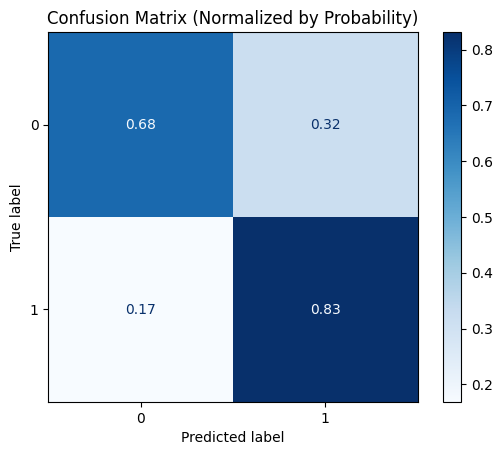


Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.68      0.74        73
           1       0.74      0.83      0.78        77

    accuracy                           0.76       150
   macro avg       0.76      0.76      0.76       150
weighted avg       0.76      0.76      0.76       150



In [46]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("\nAccuracy:", accuracy_score(results["true_label"], results["predicted_label"]))
ConfusionMatrixDisplay.from_predictions(results["true_label"], results["predicted_label"], cmap='Blues', normalize='true')
plt.title("Confusion Matrix (Normalized by Probability)")
plt.show()
print("\nClassification Report:\n", classification_report(results["true_label"], results["predicted_label"]))

TASK-4

In [47]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [48]:
vectorizer = CountVectorizer(
    max_df=0.9,         
    min_df=1,          
    stop_words="english" 
)    

X_counts = vectorizer.fit_transform(data["text"])

print("Document-Term Matrix shape:", X_counts.shape)


Document-Term Matrix shape: (748, 2403)


In [49]:
lda = LatentDirichletAllocation(
    n_components=10,      
    random_state=42,
    learning_method="batch"  
)

lda.fit(X_counts)
print("LDA trained with 10 topics.")


LDA trained with 10 topics.


Print top words for each topic

In [50]:
feature_names = vectorizer.get_feature_names_out()

n_top_words = 10  
for topic_idx, topic_weights in enumerate(lda.components_):
    top_word_indices = topic_weights.argsort()[-n_top_words:][::-1]
    top_words = [feature_names[i] for i in top_word_indices]
    
    print(f"\nTopic {topic_idx+1}:")
    print(", ".join(top_words))



Topic 1:
movie, film, think, awful, recommend, like, bad, really, right, look

Topic 2:
movie, watch, say, think, rent, episode, work, mean, rating, plot

Topic 3:
film, watch, movie, bad, look, time, actor, excellent, play, boring

Topic 4:
movie, write, like, act, bad, look, come, scamp, film, beautiful

Topic 5:
bad, act, movie, character, know, make, good, think, really, write

Topic 6:
film, understand, great, waste, music, little, scene, know, masterpiece, cast

Topic 7:
movie, make, bad, really, thing, film, character, funny, work, minute

Topic 8:
movie, plot, love, film, character, way, worth, real, time, enjoy

Topic 9:
film, movie, good, make, great, bad, like, character, act, line

Topic 10:
movie, film, time, like, script, character, story, bad, suck, actor


In [51]:
doc_topic_probs = lda.transform(X_counts)  # shape: (num_docs, 10)
dominant_topic = np.argmax(doc_topic_probs, axis=1)

data["dominant_topic"] = dominant_topic

data[["text", "dominant_topic"]].head(10)


,text,dominant_topic
0,slow move aimless movie distress drift young man,8
1,not sure lose flat character audience nearly half walk,0
2,attempt artiness black white clever camera angle movie disappoint become even ridiculous act poor plot line almost non existent,4
3,little music anything speak,5
4,best scene movie gerardo try find song keep run head,2
5,rest movie lack art charm meaning emptiness work guess empty,8
6,waste two hour,9
7,saw movie today think good effort good message kid,0
8,bit predictable,9
9,love cast jimmy buffet science teacher,7


In [52]:
for t in range(10):
    print("\n" + "="*80)
    print(f"TOPIC {t} — Sample documents")
    print("="*80)
    
    samples = data[data["dominant_topic"] == t]["text"].head(3).tolist()
    if len(samples) == 0:
        print("No documents assigned to this topic (common with small datasets).")
    else:
        for s in samples:
            print("-", s)



TOPIC 0 — Sample documents
- not sure lose flat character audience nearly half walk
- saw movie today think good effort good message kid
- right case movie delivers everything almost right face

TOPIC 1 — Sample documents
- generally line plot weak average episode
- advise anyone go see
- several moment movie need excruciatingly slow move

TOPIC 2 — Sample documents
- best scene movie gerardo try find song keep run head
- give one look
- suspense feel frustration retard girl

TOPIC 3 — Sample documents
- average act main person low budget clearly see
- act bad dialog extremely shallow insincere
- term write fresh bold

TOPIC 4 — Sample documents
- attempt artiness black white clever camera angle movie disappoint become even ridiculous act poor plot line almost non existent
- movie show lot florida best make look appeal
- wind lion well write superbly act

TOPIC 5 — Sample documents
- little music anything speak
- practically perfect  true masterpiece sea faux masterpiece
- actually t

In [53]:
#to checking the overlap

topic_top_words = []
for topic_idx, topic_weights in enumerate(lda.components_):
    top_word_indices = topic_weights.argsort()[-n_top_words:][::-1]
    top_words = [feature_names[i] for i in top_word_indices]
    topic_top_words.append(set(top_words))

# Compare each pair of topics by how many top-words overlap
for i in range(10):
    for j in range(i+1, 10):
        overlap = len(topic_top_words[i].intersection(topic_top_words[j]))
        if overlap >= 3:  # threshold you can adjust
            print(f"Topic {i+1} and Topic {j+1} overlap by {overlap} top-words.")


Topic 1 and Topic 3 overlap by 4 top-words.
Topic 1 and Topic 4 overlap by 5 top-words.
Topic 1 and Topic 5 overlap by 4 top-words.
Topic 1 and Topic 7 overlap by 4 top-words.
Topic 1 and Topic 9 overlap by 4 top-words.
Topic 1 and Topic 10 overlap by 4 top-words.
Topic 3 and Topic 4 overlap by 4 top-words.
Topic 3 and Topic 7 overlap by 3 top-words.
Topic 3 and Topic 8 overlap by 3 top-words.
Topic 3 and Topic 9 overlap by 3 top-words.
Topic 3 and Topic 10 overlap by 5 top-words.
Topic 4 and Topic 5 overlap by 4 top-words.
Topic 4 and Topic 7 overlap by 3 top-words.
Topic 4 and Topic 9 overlap by 5 top-words.
Topic 4 and Topic 10 overlap by 4 top-words.
Topic 5 and Topic 7 overlap by 5 top-words.
Topic 5 and Topic 9 overlap by 6 top-words.
Topic 5 and Topic 10 overlap by 3 top-words.
Topic 7 and Topic 8 overlap by 3 top-words.
Topic 7 and Topic 9 overlap by 5 top-words.
Topic 7 and Topic 10 overlap by 4 top-words.
Topic 8 and Topic 9 overlap by 3 top-words.
Topic 8 and Topic 10 overla